# Tutorial 11 — Extending Chemistry and Scoring Contexts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/11_extending_chemistry_and_scoring.ipynb)

TMol separates chemical identity, packed device metadata, coordinate interchange, and scoring parameters. This advanced tutorial makes those layers explicit, builds a stable chemistry subset, and measures the effect of changing one Cartesian bonded parameter without mutating the process-wide default database.

## Learning objectives

By the end, you will be able to:

- distinguish `ParameterDatabase`, `ResidueTypeSet`, `PackedBlockTypes`, and `CanonicalOrdering`;
- create a reproducible chemical subset and use it to build a pose;
- construct focused score functions with explicit weights;
- derive a modified immutable scoring database and verify its local effect;
- decide when a custom database is appropriate instead of a task- or score-weight change.

## Before you begin

Complete [Working with TMol](01_working_with_tmol.ipynb), [Scoring and Analysis](03_scoring_and_analysis.ipynb), and [Ligands and Parameter Files](07_ligand_and_params.ipynb) first. This notebook is for developers extending TMol's model rather than ordinary structure scoring. A smaller packed type set is an engineering choice, not a new force field, and changing a bonded spring constant creates a different model whose results require independent validation.


## Setup

**Run in Colab:** Use the badge above, select **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**. The setup installs TMol and downloads any listed fixtures; allow extra time for installation and the first calculation. For local execution, follow the [installation guide](../installation.md) and use a kernel with TMol installed.

No external structures are downloaded. The examples build a five-residue peptide from sequence using the chemistry shipped with the currently installed TMol release. The setup reports exact package versions and uses the selected CPU or CUDA device.


In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab([])


In [2]:
import copy

import attrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import tmol
from tmol.chemical import ResidueTypeSet
from tmol.database import ParameterDatabase
from tmol.database.scoring import CartBondedDatabase
from tmol.pose import PackedBlockTypes
from tmol.score import ScoreFunction, ScoreType, beta2016_score_function

SEED = 20260910
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)


def show_table(frame):
    """Use a sortable table in rendered docs, with a pandas fallback."""
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


environment_frame = pd.DataFrame(
    [
        {"component": "TMol", "version": tmol.__version__},
        {"component": "PyTorch", "version": torch.__version__},
        {"component": "device", "version": str(device)},
    ]
)
show_table(environment_frame)


## Follow the data model from chemistry to a score

`ParameterDatabase` is the immutable source of chemical and scoring parameters. `ResidueTypeSet` refines base residue records with variants such as termini. `PackedBlockTypes` moves a chosen, ordered set of those refined types onto one device and becomes the cache shared by poses and score terms. `CanonicalOrdering` instead defines stable external tensor indices for residue-equivalence classes and atoms.

A `ScoreFunction` owns weights and energy-term options. Rendering it for a `PoseStack` prepares topology-dependent tensors; coordinate tensors can then change without rebuilding the chemical layout. The diagram is an ownership map, not a runtime call graph.


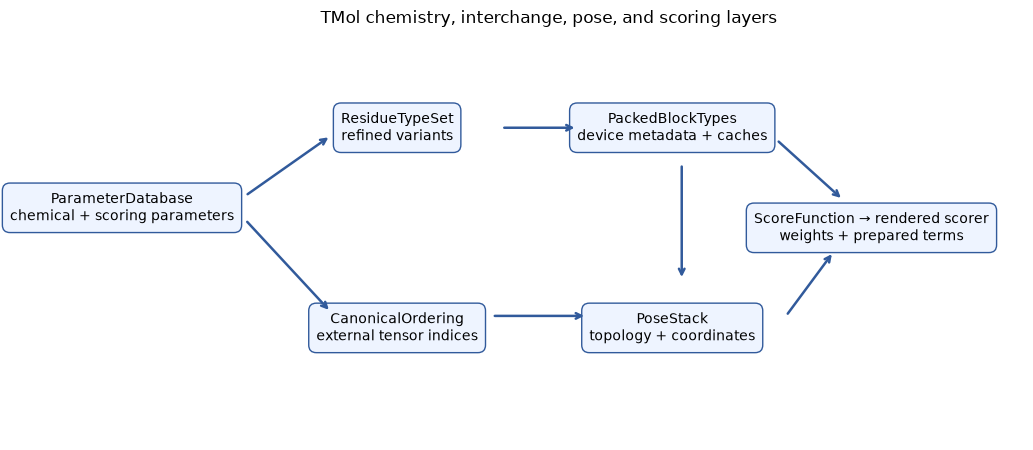

In [3]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.set_axis_off()
boxes = {
    "ParameterDatabase\nchemical + scoring parameters": (0.05, 0.58),
    "ResidueTypeSet\nrefined variants": (0.34, 0.78),
    "CanonicalOrdering\nexternal tensor indices": (0.34, 0.28),
    "PackedBlockTypes\ndevice metadata + caches": (0.63, 0.78),
    "PoseStack\ntopology + coordinates": (0.63, 0.28),
    "ScoreFunction → rendered scorer\nweights + prepared terms": (0.84, 0.53),
}
for label, (x, y) in boxes.items():
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="center",
        va="center",
        bbox={"boxstyle": "round,pad=0.55", "fc": "#eef4ff", "ec": "#315a9b"},
    )
arrows = [
    ((0.18, 0.61), (0.27, 0.76)),
    ((0.18, 0.55), (0.27, 0.32)),
    ((0.45, 0.78), (0.53, 0.78)),
    ((0.44, 0.31), (0.54, 0.31)),
    ((0.64, 0.69), (0.64, 0.40)),
    ((0.75, 0.31), (0.80, 0.47)),
    ((0.74, 0.75), (0.81, 0.60)),
]
for start, end in arrows:
    ax.annotate("", xy=end, xytext=start, xycoords="axes fraction", arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "#315a9b"})
ax.set_title("TMol chemistry, interchange, pose, and scoring layers", pad=12)
plt.tight_layout()
plt.show()


## Inspect the default refined chemistry

The raw database contains base residue definitions and named patches. Refinement materializes usable block types such as terminal amino acids and nucleic-acid termini. Counting refined types by polymer backbone makes it clear why a general-purpose packed set is larger than the twenty canonical amino acids.


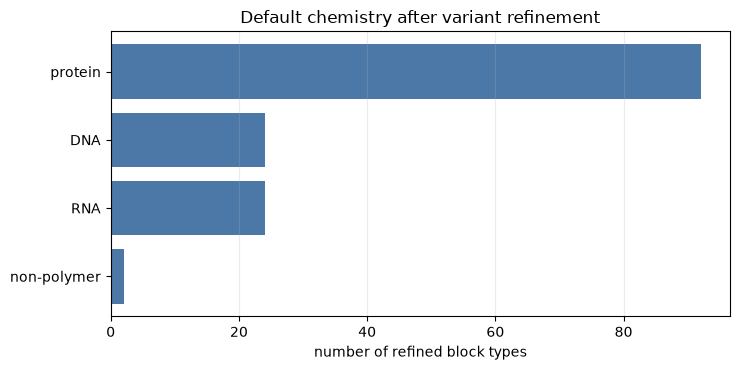

In [4]:
parameter_db = ParameterDatabase.get_default()
residue_type_set = ResidueTypeSet.from_database(parameter_db.chemical)


def chemistry_family(residue_type):
    polymer = residue_type.properties.polymer
    if not polymer.is_polymer:
        return "non-polymer"
    if polymer.backbone_type == "alpha":
        return "protein"
    if polymer.backbone_type == "dna":
        return "DNA"
    if polymer.backbone_type == "rna":
        return "RNA"
    return polymer.backbone_type or "other polymer"


inventory_frame = pd.DataFrame(
    [
        {
            "block_type": residue_type.name,
            "name3": residue_type.name3,
            "family": chemistry_family(residue_type),
            "atoms": len(residue_type.atoms),
            "torsions": len(residue_type.torsions),
        }
        for residue_type in residue_type_set.residue_types
    ]
)
family_counts = (
    inventory_frame.groupby("family", as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .rename(columns={"size": "refined_block_types"})
)
show_table(family_counts)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(
    family_counts["family"][::-1],
    family_counts["refined_block_types"][::-1],
    color="#4c78a8",
)
ax.set(
    xlabel="number of refined block types",
    title="Default chemistry after variant refinement",
)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


**Expected observations.** Protein block types dominate the refined inventory because base residues acquire compatible terminal and other variants. These are chemical alternatives, not additional sequence positions. Code that assumes one packed type per one-letter amino-acid code will fail on termini, protonation variants, nucleic acids, and non-polymers.


## Build a stable, explicit chemistry subset

`create_stable_subset()` selects base residue names and named variants while preserving a deterministic order as the source database grows. The complete scoring database is retained, but only the requested chemistry is refined and packed. This is useful for a controlled application with a known alphabet; it is unsafe when incoming structures may contain chemistry outside that alphabet.

The example keeps ALA, GLY, SER, and PRO plus protein termini. It then builds `AGSPA`, proving that the subset contains every internal and terminal type required by that sequence.


In [5]:
subset_db = parameter_db.create_stable_subset(
    desired_names=["ALA", "GLY", "SER", "PRO"],
    desired_variants=["nterm", "cterm"],
)
subset_restype_set = ResidueTypeSet.from_database(subset_db.chemical)
subset_pbt = PackedBlockTypes.from_restype_list(
    subset_db.chemical,
    subset_restype_set,
    subset_restype_set.residue_types,
    device,
)
subset_ordering = tmol.CanonicalOrdering.from_chemdb(subset_db.chemical)
peptide = tmol.extended_pose_stack_from_sequences(
    "AGSPA", device=device, param_db=subset_db
)

subset_frame = pd.DataFrame(
    [
        {
            "context": "default refined chemistry",
            "refined_types": len(residue_type_set.residue_types),
            "packed_types": tmol.default_packed_block_types(device).n_types,
            "canonical_equivalence_classes": tmol.default_canonical_ordering().n_restype_io_equiv_classes,
        },
        {
            "context": "AGSP subset",
            "refined_types": len(subset_restype_set.residue_types),
            "packed_types": subset_pbt.n_types,
            "canonical_equivalence_classes": subset_ordering.n_restype_io_equiv_classes,
        },
    ]
)
show_table(subset_frame)
print("pose block types:", [peptide.block_type(0, i).name for i in range(peptide.max_n_blocks)])

try:
    peptide_viewer = tmol.view(peptide, width=720, height=380)
    peptide_viewer.show()
except ImportError as exc:
    print("Interactive peptide viewer unavailable:", exc)


pose block types: ['ALA:nterm', 'GLY', 'SER', 'PRO', 'ALA:cterm']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Expected observations.** The subset packs far fewer types but still builds a chemically complete terminated peptide. The interactive viewer shows coordinates generated from the subset's ideal internal geometry. The viewer does not validate the energy model, and an extended pose is not a folded structure.


## Separate score weights from score parameters

Use weights when an existing energy term should contribute differently. Use a modified `ParameterDatabase` only when the term's underlying model changes. The focused score function below gives only Cartesian bond-length energy a nonzero weight. Cartesian length, angle, torsion, improper, and hydroxyl-torsion lanes share one implementation term, so rendering it exposes all five lanes even when four weights are zero. Setting every lane owned by a term to zero removes that implementation term.


In [6]:
beta = beta2016_score_function(device, param_db=subset_db)
focused = ScoreFunction(subset_db, device)
focused.set_weight(ScoreType.cart_lengths, 1.0)

weight_rows = []
for score_type in beta.all_score_types():
    weight = float(beta.get_weight(score_type).detach().cpu())
    if weight != 0.0:
        weight_rows.append(
            {"score_type": score_type.name, "beta2016_weight": weight}
        )
weight_frame = pd.DataFrame(weight_rows)
weight_frame["focused_cart_length_weight"] = weight_frame["score_type"].map(
    {"cart_lengths": 1.0}
).fillna(0.0)
show_table(weight_frame)
focused_nonzero = [
    score_type
    for score_type in focused.all_score_types()
    if float(focused.get_weight(score_type).detach().cpu()) != 0.0
]
print("focused rendered score lanes:", [st.name for st in focused.all_score_types()])
print("focused nonzero weights:", [st.name for st in focused_nonzero])
assert focused_nonzero == [ScoreType.cart_lengths]


focused rendered score lanes: ['cart_lengths', 'cart_angles', 'cart_torsions', 'cart_impropers', 'cart_hxltorsions']
focused nonzero weights: ['cart_lengths']


## Change one immutable Cartesian bonded parameter

This extension-level example doubles the spring constant for the intraproline N–CD bond. `attrs.evolve()` and `CartBondedDatabase.from_cartres_dict()` create new immutable database layers; the shared default remains untouched.

To isolate the change, the code displaces only the internal proline CD atom and compares two score functions containing only `cart_lengths`. Plotting relative energies removes any constant offset. This is a sensitivity test of one implementation change—not parameter fitting, physical calibration, or evidence that the altered model is better.


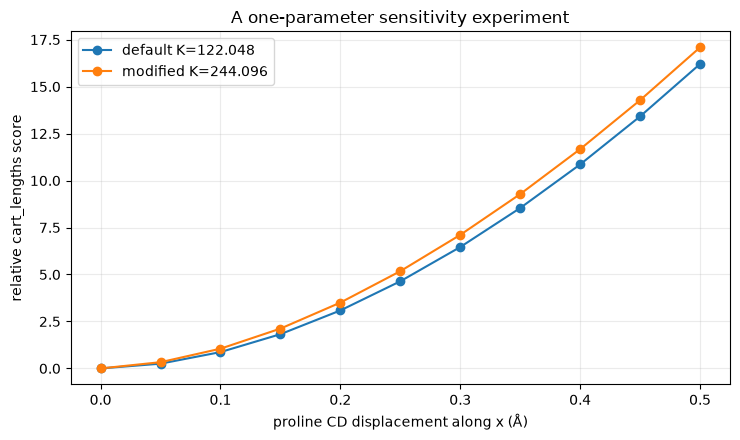

In [7]:
cart_db = subset_db.scoring.cartbonded
pro_params = cart_db.residue_params["PRO"]
parameter_index, original_n_cd = next(
    (index, parameter)
    for index, parameter in enumerate(pro_params.length_parameters)
    if {parameter.atm1, parameter.atm2} == {"N", "CD"}
)
strengthened_n_cd = attrs.evolve(original_n_cd, K=2.0 * original_n_cd.K)
strengthened_lengths = list(pro_params.length_parameters)
strengthened_lengths[parameter_index] = strengthened_n_cd
strengthened_pro = attrs.evolve(
    pro_params, length_parameters=tuple(strengthened_lengths)
)
strengthened_residue_params = copy.deepcopy(cart_db.residue_params)
strengthened_residue_params["PRO"] = strengthened_pro
strengthened_cart_db = CartBondedDatabase.from_cartres_dict(
    cartres_dict=strengthened_residue_params
)
strengthened_scoring_db = attrs.evolve(
    subset_db.scoring, cartbonded=strengthened_cart_db
)
strengthened_db = attrs.evolve(subset_db, scoring=strengthened_scoring_db)

standard_cart = ScoreFunction(subset_db, device)
standard_cart.set_weight(ScoreType.cart_lengths, 1.0)
strengthened_cart = ScoreFunction(strengthened_db, device)
strengthened_cart.set_weight(ScoreType.cart_lengths, 1.0)
standard_scorer = standard_cart.render_whole_pose_scoring_module(peptide)
strengthened_scorer = strengthened_cart.render_whole_pose_scoring_module(peptide)

pro_block = next(
    index
    for index in range(peptide.max_n_blocks)
    if peptide.block_type(0, index).name3 == "PRO"
)
pro_type = peptide.block_type(0, pro_block)
pro_offset = int(peptide.block_coord_offset64[0, pro_block])
pro_cd = pro_offset + pro_type.atom_to_idx["CD"]

displacement_values = np.linspace(0.0, 0.50, 11)
scan_rows = []
displaced_coords = None
for displacement in displacement_values:
    coords = peptide.coords.clone()
    coords[0, pro_cd, 0] += float(displacement)
    if displacement == displacement_values[-1]:
        displaced_coords = coords
    scan_rows.append(
        {
            "CD_x_displacement_A": displacement,
            "standard_cart_lengths": float(standard_scorer(coords).detach().cpu()[0]),
            "strengthened_cart_lengths": float(strengthened_scorer(coords).detach().cpu()[0]),
        }
    )

scan_frame = pd.DataFrame(scan_rows)
for column in ["standard_cart_lengths", "strengthened_cart_lengths"]:
    scan_frame[f"relative_{column}"] = scan_frame[column] - scan_frame[column].iloc[0]
show_table(scan_frame.iloc[[0, 2, 5, 10]])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(
    scan_frame["CD_x_displacement_A"],
    scan_frame["relative_standard_cart_lengths"],
    marker="o",
    label=f"default K={original_n_cd.K:g}",
)
ax.plot(
    scan_frame["CD_x_displacement_A"],
    scan_frame["relative_strengthened_cart_lengths"],
    marker="o",
    label=f"modified K={strengthened_n_cd.K:g}",
)
ax.set(
    xlabel="proline CD displacement along x (Å)",
    ylabel="relative cart_lengths score",
    title="A one-parameter sensitivity experiment",
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

assert parameter_db.scoring.cartbonded.residue_params["PRO"].length_parameters != strengthened_pro.length_parameters
assert scan_frame["relative_strengthened_cart_lengths"].iloc[-1] > scan_frame["relative_standard_cart_lengths"].iloc[-1]


In [8]:
displaced_peptide = attrs.evolve(peptide, coords=displaced_coords)
try:
    display(
        tmol.switchable_view(
            {
                "ideal input": peptide,
                "CD displaced by 0.50 Å": displaced_peptide,
            },
            notes={
                "ideal input": "Subset-built AGSPA peptide",
                "CD displaced by 0.50 Å": "Only the internal proline CD coordinate was translated",
            },
            width=720,
            height=380,
        )
    )
except ImportError as exc:
    print("Interactive comparison unavailable:", exc)


**Expected observations.** The modified curve rises more steeply because only the selected spring constant changed. The switcher confirms that the coordinate experiment is local. The absolute curve includes all bond-length deviations in the peptide, so the difference between curves—not either absolute value—is the cleanest diagnostic of this parameter change.

## Extension checklist

Before shipping a custom database:

1. Keep the source database immutable and construct a derived object.
2. Build the smallest pose that exercises the modified chemistry.
3. Compare changed and unchanged parameters explicitly.
4. Test values and coordinate gradients on CPU and CUDA.
5. Validate complete scientific workflows separately from local unit tests.
6. Record the parameter provenance and never label TMol score units as kcal/mol.

## Exercises

1. Add VAL to the stable subset and verify that `AGSPV` builds without changing the existing packed-type order.
2. Change the focused score function to contain `cart_angles` instead of `cart_lengths`; perturb an angle-defining coordinate and plot the response.
3. Repeat the N–CD scan with gradients enabled and compare `dE/dx` between the two parameterizations.

## References

- [Tutorial 01 — Working with TMol](01_working_with_tmol.ipynb)
- [Tutorial 03 — Scoring and Analysis](03_scoring_and_analysis.ipynb)
- [Tutorial 07 — Ligands and Parameter Files](07_ligand_and_params.ipynb)
- [Database API](../api/database.rst)
- [Pose API](../api/pose.rst)
- [Score API](../api/score.rst)
